In [1]:
# 1. Datenimport und Datenaufbereitung
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load Data
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

In [3]:
# Daten Aufbereitung
# Datum + Zeit kombinieren
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

# Als Index setzen
df.set_index("Datetime", inplace=True)

# Alte Spalten entfernen
df.drop(columns=["Date", "Time"], inplace=True)

In [4]:
# Missing values analysieren
df.isna().sum()
(df.isna().sum() / len(df)) * 100

# Fehlende Werte Tabelle
missing = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "percentage": (df.isna().sum() / len(df)) * 100
})

missing[missing["missing_values"] > 0]

,missing_values,percentage
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


In [5]:
# Timestamps mit missing values
df_missing = df[df.isna().any(axis=1)]

df_missing.index

DatetimeIndex(['2006-12-21 11:23:00', '2006-12-21 11:24:00',
               '2006-12-30 10:08:00', '2006-12-30 10:09:00',
               '2007-01-14 18:36:00', '2007-01-28 17:13:00',
               '2007-02-22 22:58:00', '2007-02-22 22:59:00',
               '2007-03-25 17:52:00', '2007-04-28 00:21:00',
               ...
               '2010-09-28 19:04:00', '2010-09-28 19:05:00',
               '2010-09-28 19:06:00', '2010-09-28 19:07:00',
               '2010-09-28 19:08:00', '2010-09-28 19:09:00',
               '2010-09-28 19:10:00', '2010-09-28 19:11:00',
               '2010-09-28 19:12:00', '2010-10-24 15:35:00'],
              dtype='datetime64[us]', name='Datetime', length=25979, freq=None)

In [6]:
# Tage mit missing values
missing_per_day = df_missing.resample("D").size()

missing_per_day[missing_per_day > 0].head()

Datetime
2006-12-21    2
2006-12-30    2
2007-01-14    1
2007-01-28    1
2007-02-22    2
dtype: int64

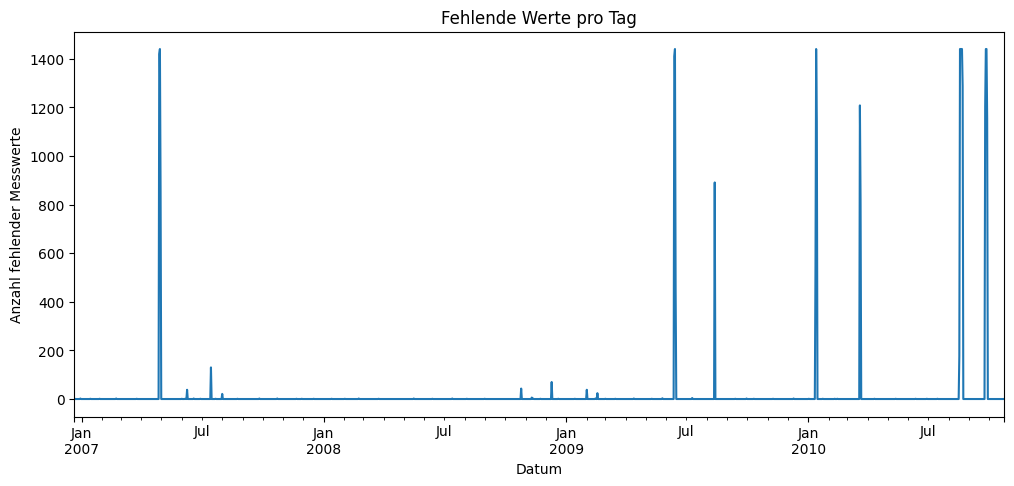

In [7]:
# Visualisierung Missing Values pro Tag
missing_per_day.plot(figsize=(12,5))

plt.title("Fehlende Werte pro Tag")
plt.xlabel("Datum")
plt.ylabel("Anzahl fehlender Messwerte")

plt.show()

In [8]:
# Ganze fehlende Tage
missing_per_day[missing_per_day > 1400]

Datetime
2007-04-28    1419
2007-04-29    1440
2009-06-13    1410
2009-06-14    1440
2010-01-13    1440
2010-08-18    1440
2010-08-19    1440
2010-08-20    1440
2010-08-21    1440
2010-09-26    1440
2010-09-27    1440
dtype: int64

In [9]:
# Missing Values entfernen
df = df.dropna()

In [10]:
# Analyse der Global_active_power in kW
# Anzahl Messwerte pro Tag
daily_counts = df["Global_active_power"].resample("D").count()

# Mindestanzahl definieren (95% von 1440 Messwerten pro Tag)
min_required = int(1440 * 0.95)

# gültige Tage bestimmen
valid_days = daily_counts[daily_counts >= min_required].index

# DataFrame auf gültige Tage reduzieren
df = df[df.index.floor("D").isin(valid_days)]

# Kontrolle
print("Verbleibende Tage:", len(valid_days))

Verbleibende Tage: 1417


In [11]:
# Arbeitskope mit bereinigten Werten
df_clean = df.copy()

In [12]:
# Zahlenformat Variable Global_active_power
df_clean["Global_active_power"] = df_clean["Global_active_power"].astype(float)

# Test
df_clean.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-17 00:00:00,1.044,0.152,242.73,4.4,0.0,2.0,0.0
2006-12-17 00:01:00,1.520,0.220,242.20,7.4,0.0,1.0,0.0
2006-12-17 00:02:00,3.038,0.194,240.14,12.6,0.0,2.0,0.0
2006-12-17 00:03:00,2.974,0.194,239.97,12.4,0.0,1.0,0.0
2006-12-17 00:04:00,2.846,0.198,240.39,11.8,0.0,2.0,0.0


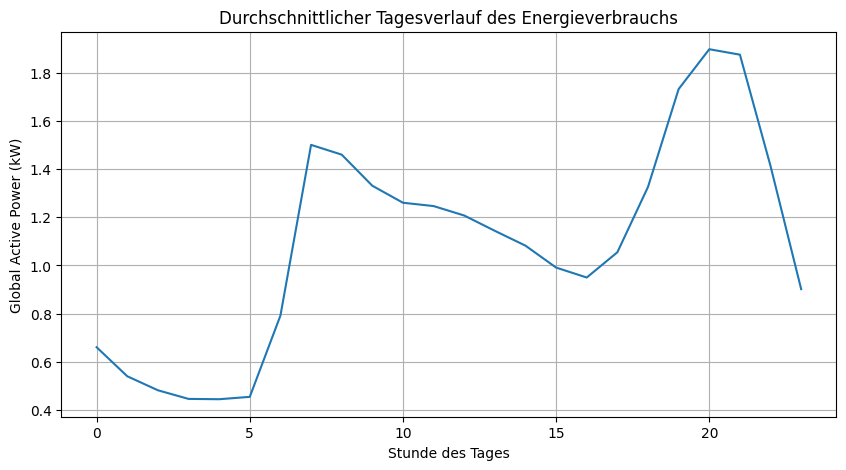

In [13]:
# 2. Explorative Analyse der Gesamtverbrauchs
# Durchschnittlicher Tagesverlauf das Erergieverbrauchs berechnen
# Neue Spalte "hour" erstellen
df_clean["hour"] = df_clean.index.hour

# Durchschnitt pro Stunde berechnen
hourly_avg = df_clean.groupby("hour")["Global_active_power"].mean()

# Visualisierung erstellen
plt.figure(figsize=(10,5))

plt.plot(hourly_avg)

plt.title("Durchschnittlicher Tagesverlauf des Energieverbrauchs")
plt.xlabel("Stunde des Tages")
plt.ylabel("Global Active Power (kW)")

plt.grid()
plt.show()



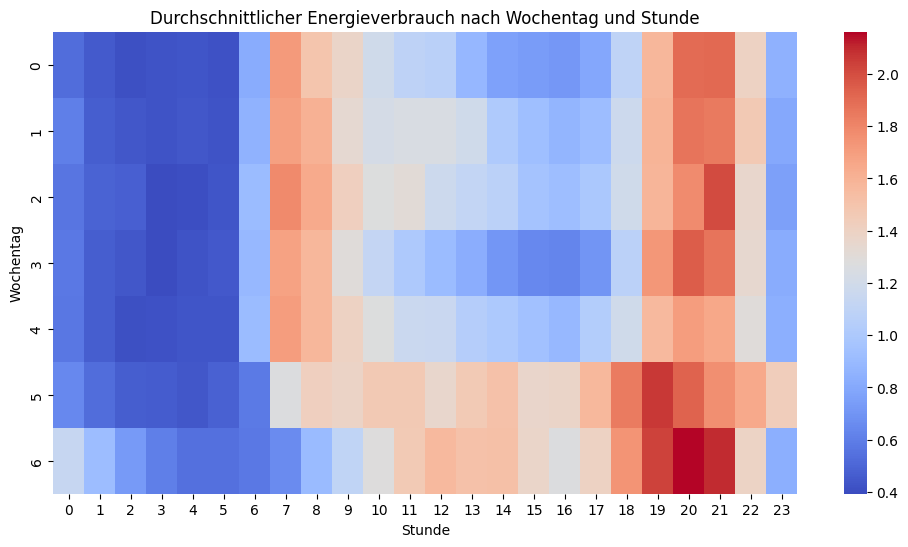

In [14]:
# Durchschnittlicher Ernergieverbauch nach Wochentag und Stunde
# Neue Spalte "weekday" erstellen
df_clean["weekday"] = df_clean.index.dayofweek

# Pivot Tabelle weekday x hour erstellen
pivot = df_clean.pivot_table(
    values="Global_active_power",
    index="weekday",
    columns="hour",
    aggfunc="mean"
)

# Visualisierung erstellen
plt.figure(figsize=(12,6))

sns.heatmap(pivot, cmap="coolwarm")

plt.title("Durchschnittlicher Energieverbrauch nach Wochentag und Stunde")
plt.xlabel("Stunde")
plt.ylabel("Wochentag")

plt.show()


In [15]:
# Lastverschiebung / Peak hours
peak_hours = df_clean.groupby("hour")["Global_active_power"].mean()

peak_hours.sort_values(ascending=False).head(5)

hour
20    1.899164
21    1.876509
19    1.733496
7     1.501448
8     1.460871
Name: Global_active_power, dtype: float64

In [16]:
# 3. Clusteranalyse typischer Nutzungstage
# Tagesaggregation
daily_features = df_clean["Global_active_power"].resample("D").agg([
    "mean", "max", "min", "sum", "std"
])

# Umrechnung der Tagessumme von kW-Minuten in kWh
daily_features["sum"] = daily_features["sum"] / 60

# Fehlende Werte entfernen
daily_features = daily_features.dropna()

# Standardisierung
scaler_daily = StandardScaler()
scaled_daily = scaler_daily.fit_transform(
    daily_features[["mean", "max", "min", "sum", "std"]]
)

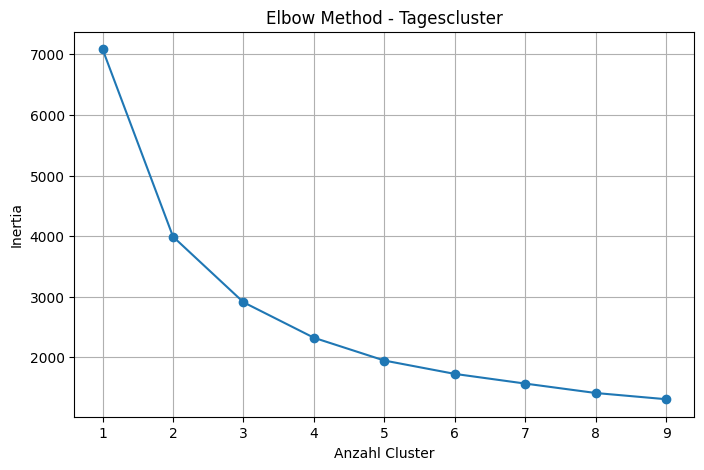

In [17]:
# Elbow Method Tagesbasis
inertia_daily = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_daily)
    inertia_daily.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_daily, marker="o")
plt.title("Elbow Method - Tagescluster")
plt.xlabel("Anzahl Cluster")
plt.ylabel("Inertia")
plt.grid()
plt.show()


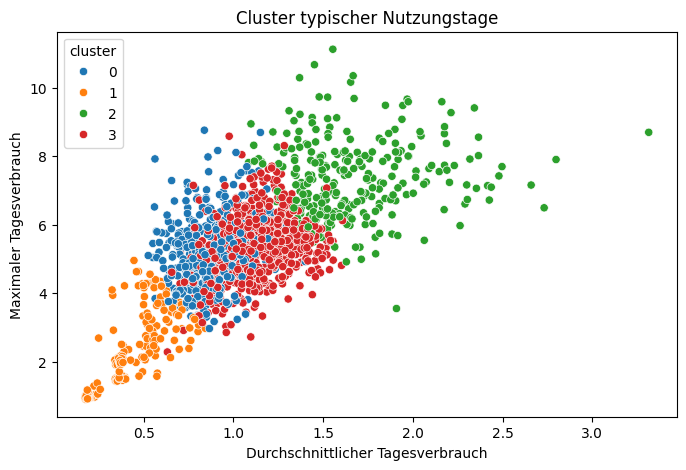

In [18]:
# Clustering Tagesbasis
kmeans_daily = KMeans(n_clusters=4, random_state=42)
daily_features["cluster"] = kmeans_daily.fit_predict(scaled_daily)

# Visualisierung Tagescluster
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=daily_features,
    x="mean",
    y="max",
    hue="cluster",
    palette="tab10"
)
plt.title("Cluster typischer Nutzungstage")
plt.xlabel("Durchschnittlicher Tagesverbrauch")
plt.ylabel("Maximaler Tagesverbrauch")
plt.show()


In [19]:
# Clusteranalyse Tagesbasis
cluster_summary_daily = daily_features.groupby("cluster").mean()
cluster_summary_daily["count"] = daily_features["cluster"].value_counts().sort_index()
print("Cluster-Zusammenfassung Tagesbasis:")
print(cluster_summary_daily)

Cluster-Zusammenfassung Tagesbasis:
             mean       max       min        sum       std  count
cluster                                                          
0        0.871492  5.300518  0.142054  20.912942  0.854841    367
1        0.455399  2.473240  0.154737  10.928293  0.396790    171
2        1.656216  7.290226  0.231048  39.740417  1.335608    292
3        1.133624  5.360600  0.236395  27.203198  0.908727    587


In [20]:
# Verteilung nach Wochentagen
daily_features["weekday"] = daily_features.index.dayofweek
print("\nVerteilung nach Wochentagen:")
print(daily_features.groupby(["cluster", "weekday"]).size())


Verteilung nach Wochentagen:
cluster  weekday
0        0           55
         1           63
         2           52
         3           57
         4           54
         5           42
         6           44
1        0           25
         1           23
         2           24
         3           29
         4           21
         5           26
         6           23
2        0           22
         1           41
         2           36
         3           20
         4           24
         5           72
         6           77
3        0          101
         1           76
         2           92
         3           97
         4          105
         5           60
         6           56
dtype: int64


In [21]:
# Verteilung nach Monaten
daily_features["month"] = daily_features.index.month
print("\nVerteilung nach Monaten:")
print(daily_features.groupby(["cluster", "month"]).size())


Verteilung nach Monaten:
cluster  month
0        2         2
         3         5
         4        13
         5        42
         6        79
         7        70
         8        51
         9        93
         10        8
         12        4
1        2        14
         3         7
         4        10
         5         3
         6        14
         7        44
         8        63
         9         4
         10        6
         11        5
         12        1
2        1        54
         2        38
         3        36
         4        17
         5        12
         6         3
         9         6
         10       32
         11       39
         12       55
3        1        67
         2        59
         3        74
         4        77
         5        67
         6        21
         7         9
         8         3
         9        13
         10       78
         11       71
         12       48
dtype: int64


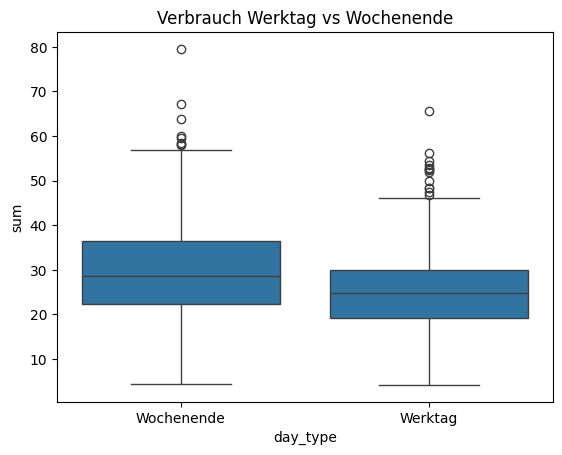

In [22]:
# Boxplot Werktag vs. Wochenende
daily_features["day_type"] = np.where(
    daily_features.index.dayofweek < 5,
    "Werktag",
    "Wochenende"
)

sns.boxplot(
    data=daily_features,
    x="day_type",
    y="sum"
)

plt.title("Verbrauch Werktag vs Wochenende")
plt.show()

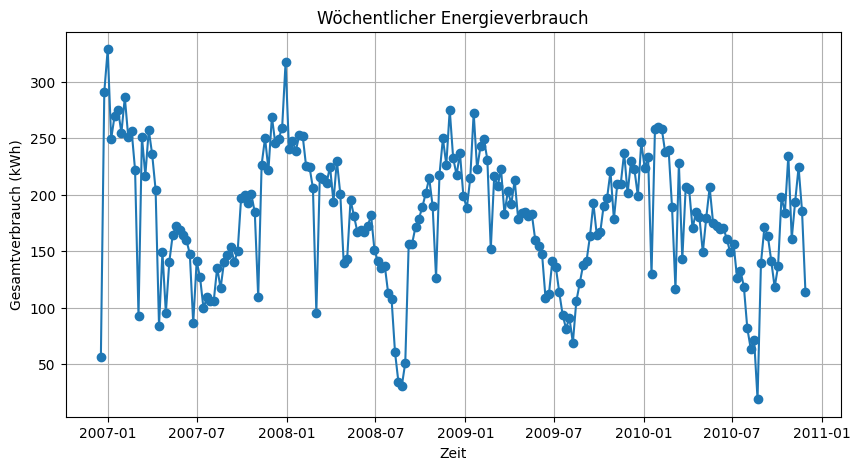

In [23]:
# 4. Wochen-, Monats- und Jahresverläufe
# Wöchentlicher Energieverbruach
weekly = df_clean["Global_active_power"].resample("W").agg([
    "sum"
])

# Umrechnung der Wochensumme von kW-Minuten in kWh
weekly["sum"] = weekly["sum"] / 60

plt.figure(figsize=(10,5))
plt.plot(weekly["sum"], marker="o")
plt.title("Wöchentlicher Energieverbrauch")
plt.xlabel("Zeit")
plt.ylabel("Gesamtverbrauch (kWh)")
plt.grid()
plt.show()

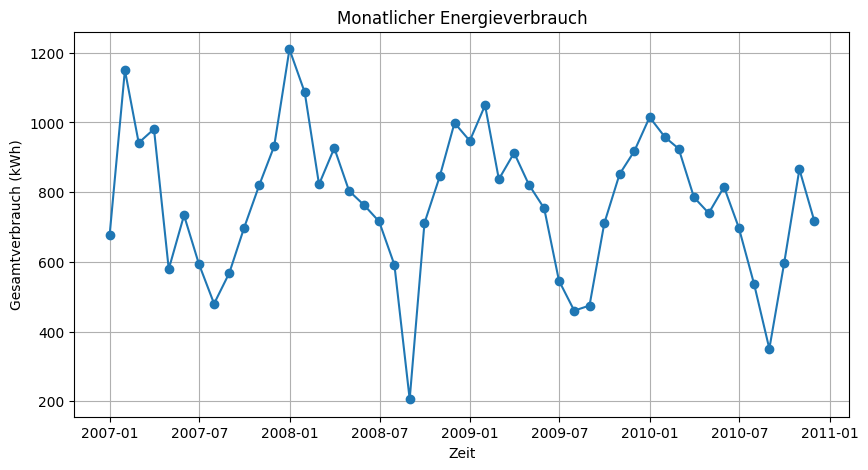

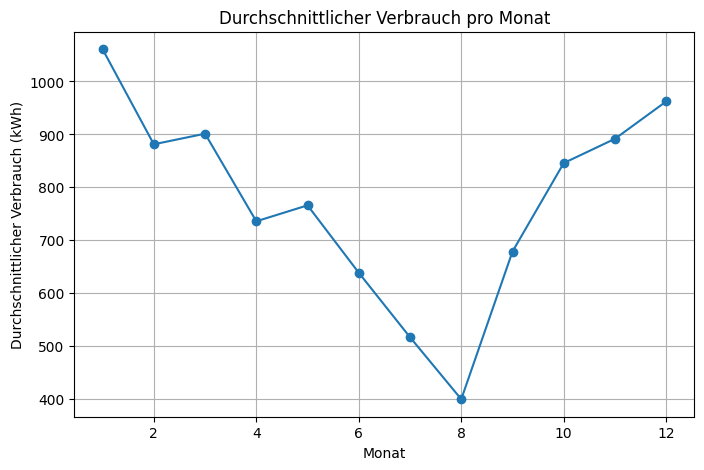

In [24]:
# Monatlicher Energieverbauch

monthly = df_clean["Global_active_power"].resample("ME").agg([
    "mean", "max", "sum", "std"
])

# Umrechnung der Monatssumme von kW-Minuten in kWh
monthly["sum"] = monthly["sum"] / 60

monthly = monthly.dropna()

# Zeitverlauf Monatsverbrauch
plt.figure(figsize=(10, 5))
plt.plot(monthly["sum"], marker="o")
plt.title("Monatlicher Energieverbrauch")
plt.xlabel("Zeit")
plt.ylabel("Gesamtverbrauch (kWh)")
plt.grid()
plt.show()

# Durchschnittlicher Verbrauch pro Kalendermonat
monthly["month"] = monthly.index.month
monthly_avg = monthly.groupby("month")["sum"].mean()

plt.figure(figsize=(8, 5))
plt.plot(monthly_avg, marker="o")
plt.title("Durchschnittlicher Verbrauch pro Monat")
plt.xlabel("Monat")
plt.ylabel("Durchschnittlicher Verbrauch (kWh)")
plt.grid()
plt.show()

monthly_features = monthly.copy()

# Features Monatsbasis
features_monthly = monthly_features[["mean", "max", "sum", "std"]]

# Standardisierung
scaler_monthly = StandardScaler()
scaled_monthly = scaler_monthly.fit_transform(features_monthly)

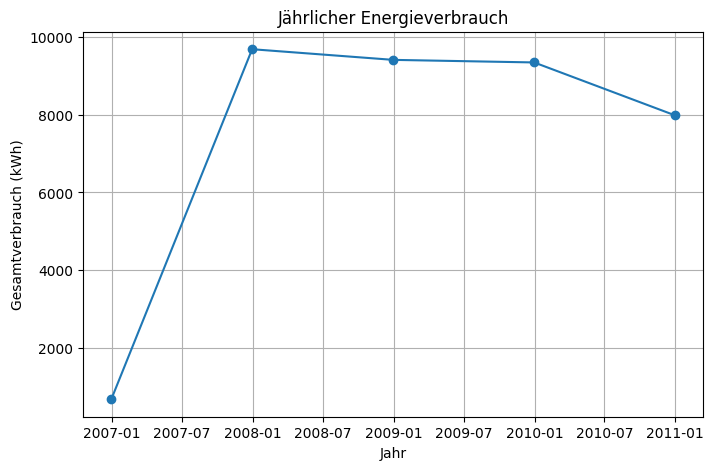

In [25]:
# Jährlicher Energieverbauch

yearly = df_clean["Global_active_power"].resample("YE").agg([
    "mean", "sum"
])

# Umrechnung der Jahressumme von kW-Minuten in kWh
yearly["sum"] = yearly["sum"] / 60

plt.figure(figsize=(8, 5))
plt.plot(yearly["sum"], marker="o")
plt.title("Jährlicher Energieverbrauch")
plt.xlabel("Jahr")
plt.ylabel("Gesamtverbrauch (kWh)")
plt.grid()
plt.show()

In [26]:
# 5. Ausreißeranalyse nach IQR-Methode
Q1 = daily_features["sum"].quantile(0.25)
Q3 = daily_features["sum"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Ausreißer filtern
outliers = daily_features[
    (daily_features["sum"] < lower_bound) |
    (daily_features["sum"] > upper_bound)
]

outliers.head(32)


,mean,max,min,sum,std,cluster,weekday,month,day_type
Datetime,,,,,,,,,
2006-12-17,2.354486,7.064,0.206,56.507667,1.205795,2,6,12,Wochenende
2006-12-23,3.314851,8.698,0.208,79.556433,1.503276,2,5,12,Wochenende
2006-12-26,2.732021,6.496,0.418,65.568500,0.957549,2,1,12,Werktag
2006-12-29,2.204439,7.238,0.216,52.906533,1.313413,2,4,12,Werktag
2006-12-31,2.426525,6.722,0.206,58.236600,1.164205,2,6,12,Wochenende
2007-01-04,2.263481,5.976,0.260,54.323533,1.160800,2,3,1,Werktag
2007-01-13,2.213065,9.272,0.212,53.113567,1.901306,2,5,1,Wochenende
2007-01-14,2.090213,7.640,0.202,50.130267,1.383875,2,6,1,Wochenende
2007-01-20,2.176203,8.658,0.218,52.228867,1.506638,2,5,1,Wochenende


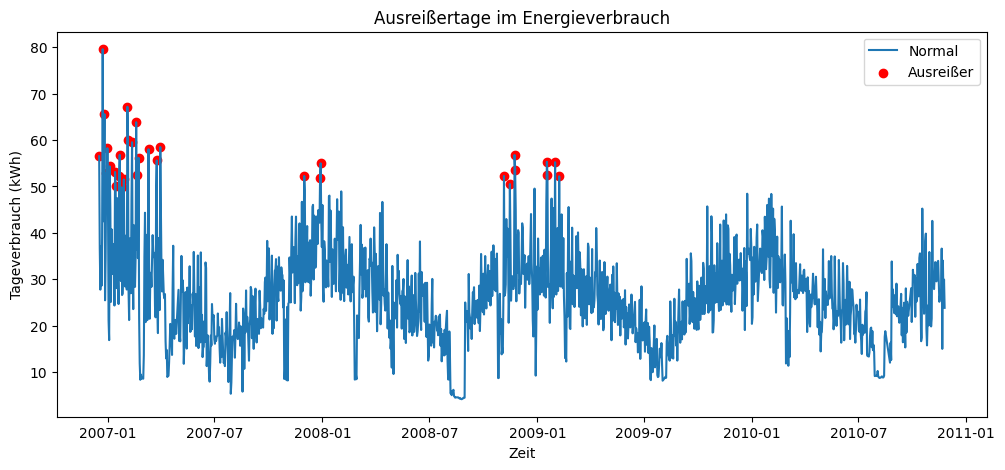

In [27]:
# Ausreißer Visualisierung
plt.figure(figsize=(12,5))

plt.plot(daily_features["sum"], label="Normal")
plt.scatter(outliers.index, outliers["sum"], color="red", label="Ausreißer")

plt.title("Ausreißertage im Energieverbrauch")
plt.xlabel("Zeit")
plt.ylabel("Tageverbrauch (kWh)")

plt.legend()
plt.show()

In [28]:
df_clean.loc["2006-12-23"]

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,weekday
Datetime,,,,,,,,,
2006-12-23 00:00:00,2.328,0.000,241.25,9.6,0.0,0.0,0.0,0,5
2006-12-23 00:01:00,2.316,0.066,241.43,9.6,0.0,0.0,0.0,0,5
2006-12-23 00:02:00,2.342,0.062,242.84,9.6,0.0,0.0,0.0,0,5
2006-12-23 00:03:00,0.564,0.000,245.04,3.8,0.0,0.0,0.0,0,5
2006-12-23 00:04:00,1.008,0.000,244.77,5.8,0.0,0.0,0.0,0,5
...,...,...,...,...,...,...,...,...,...
2006-12-23 23:55:00,3.528,0.104,243.35,14.4,0.0,0.0,18.0,23,5
2006-12-23 23:56:00,4.450,0.060,242.55,18.8,0.0,0.0,18.0,23,5
2006-12-23 23:57:00,5.574,0.054,242.28,23.0,0.0,0.0,18.0,23,5


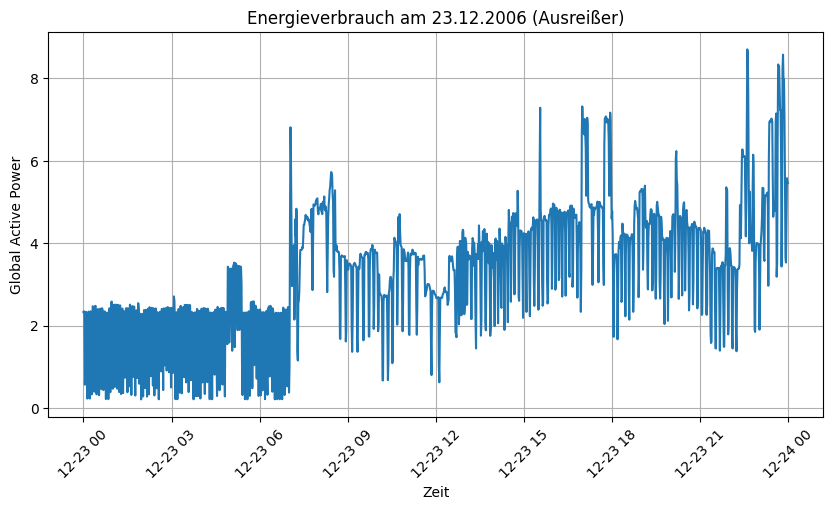

In [29]:
# Visualisierung
day = df_clean.loc["2006-12-23"]

plt.figure(figsize=(10,5))
plt.plot(day.index, day["Global_active_power"])

plt.title("Energieverbrauch am 23.12.2006 (Ausreißer)")
plt.xlabel("Zeit")
plt.ylabel("Global Active Power")

plt.xticks(rotation=45)
plt.grid()

plt.show()

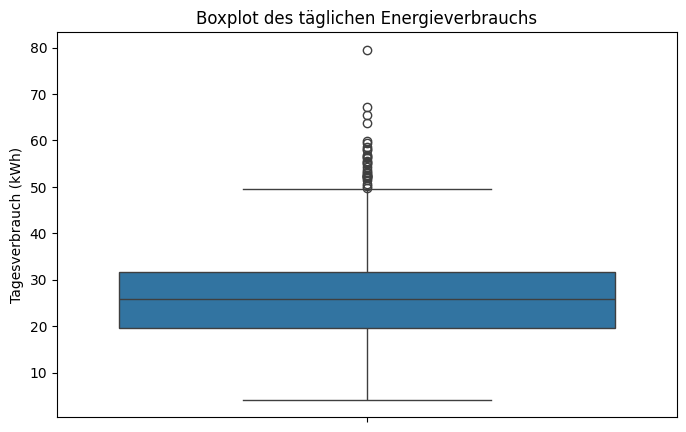

In [30]:
# Boxplot Ausreißeranalyse
plt.figure(figsize=(8,5))

sns.boxplot(y=daily_features["sum"])

plt.title("Boxplot des täglichen Energieverbrauchs")
plt.ylabel("Tagesverbrauch (kWh)")

plt.show()

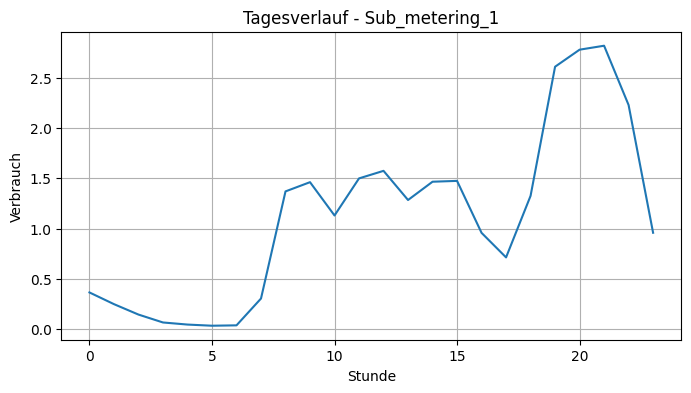

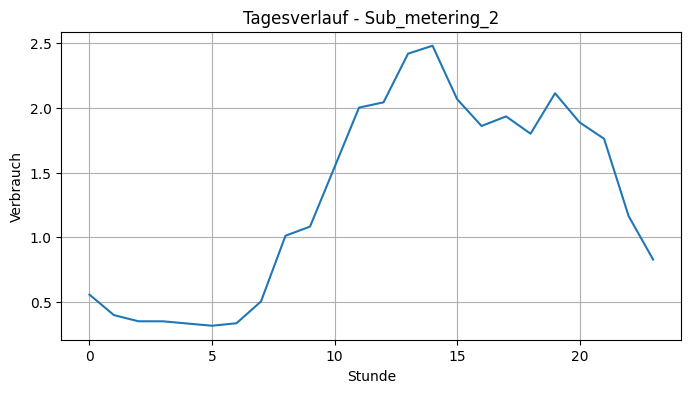

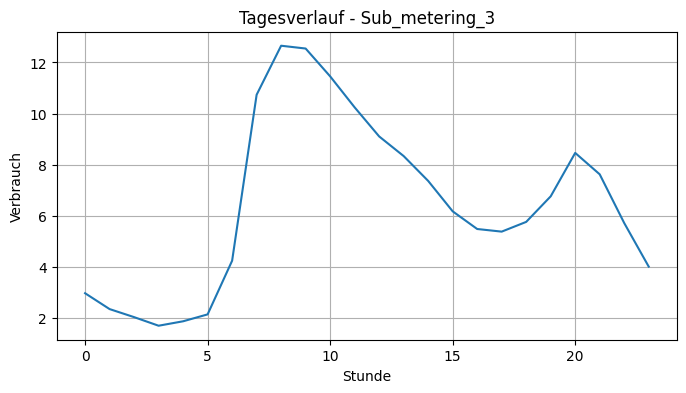

In [31]:
# 6. Analyse der Sub-meterings
# Durchschnittlicher Tagesverlauf je Sub-Metering
for col in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]:
    df_clean["hour"] = df_clean.index.hour
    
    hourly = df_clean.groupby("hour")[col].mean()
    
    plt.figure(figsize=(8,4))
    plt.plot(hourly)
    plt.title(f"Tagesverlauf - {col}")
    plt.xlabel("Stunde")
    plt.ylabel("Verbrauch")
    plt.grid()
    plt.show()

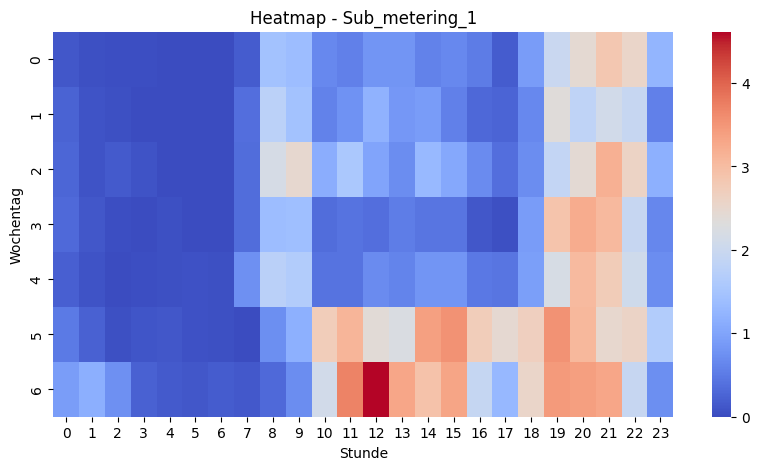

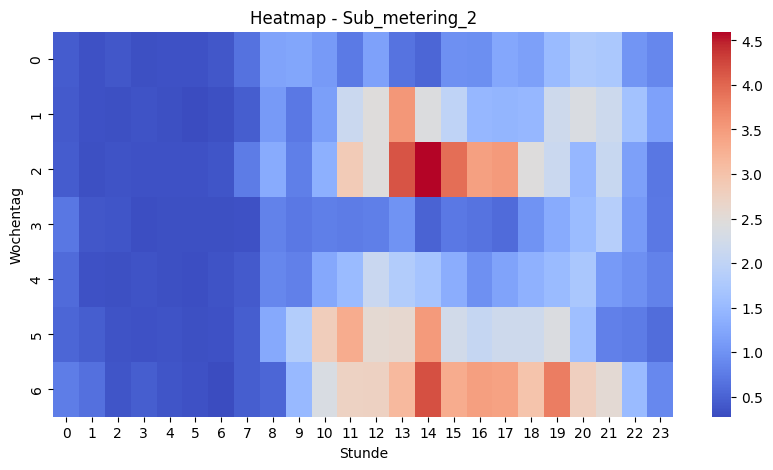

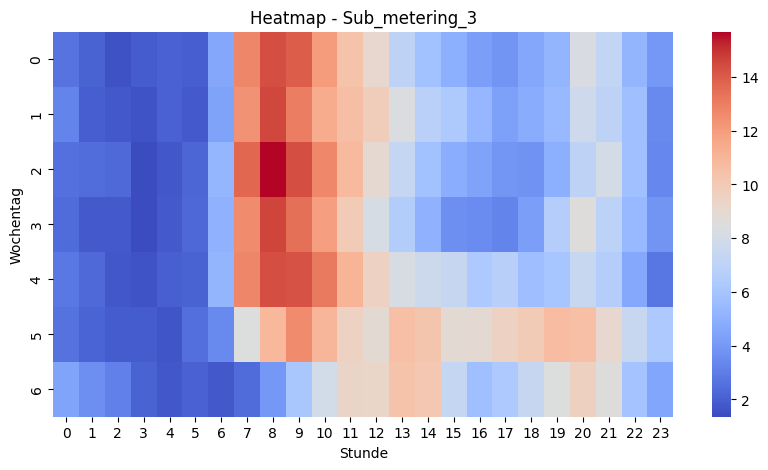

In [32]:
# Visualisierung als Heatmap
for col in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]:
    
    pivot = df_clean.pivot_table(
        values=col,
        index=df_clean.index.dayofweek,
        columns=df_clean.index.hour,
        aggfunc="mean"
    )

    plt.figure(figsize=(10,5))
    sns.heatmap(pivot, cmap="coolwarm")
    
    plt.title(f"Heatmap - {col}")
    plt.xlabel("Stunde")
    plt.ylabel("Wochentag")
    
    plt.show()

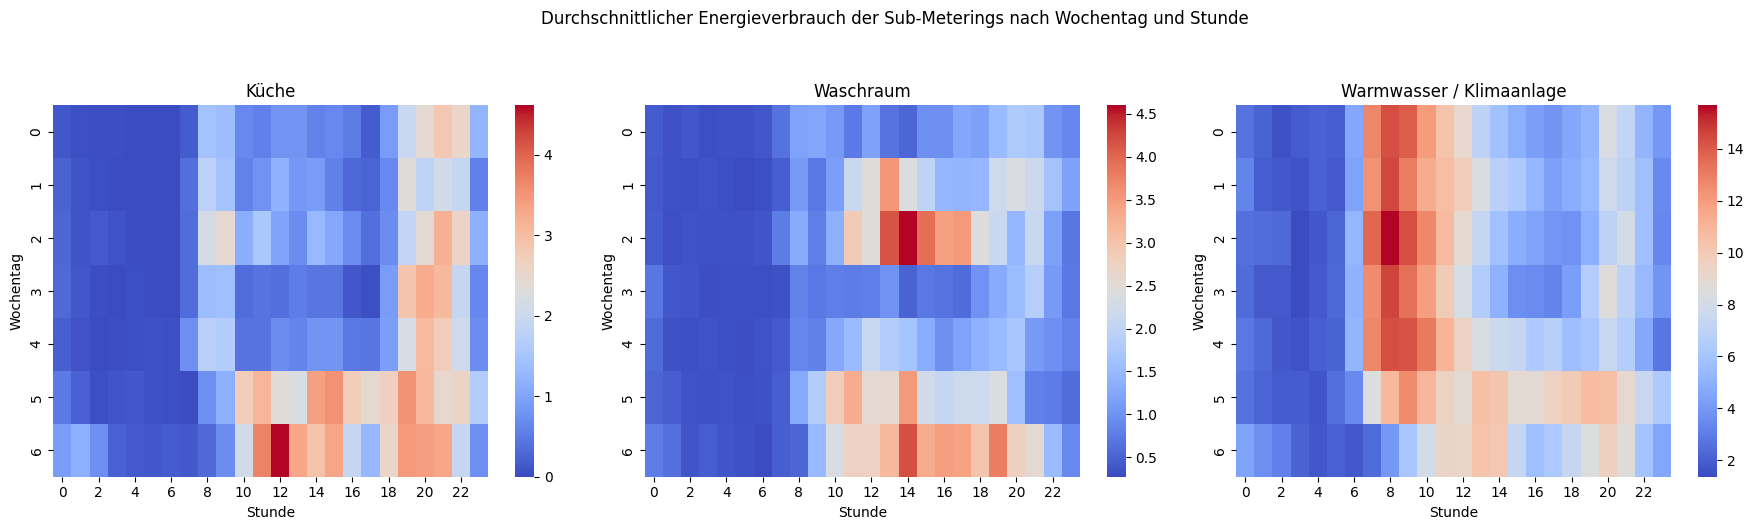

In [33]:
# Heatmaps der Sub-Meterings in einer gemeinsamen Abbildung

submeterings = {
    "Sub_metering_1": "Küche",
    "Sub_metering_2": "Waschraum",
    "Sub_metering_3": "Warmwasser / Klimaanlage"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)
axes = axes[0]

for i, (col, label) in enumerate(submeterings.items()):
    
    pivot = df_clean.pivot_table(
        values=col,
        index=df_clean.index.dayofweek,
        columns=df_clean.index.hour,
        aggfunc="mean"
    )

    sns.heatmap(
        pivot,
        cmap="coolwarm",
        ax=axes[i],
        cbar=True
    )

    axes[i].set_title(label)
    axes[i].set_xlabel("Stunde")
    axes[i].set_ylabel("Wochentag")

plt.suptitle("Durchschnittlicher Energieverbrauch der Sub-Meterings nach Wochentag und Stunde", y=1.05)
plt.tight_layout()
plt.show()

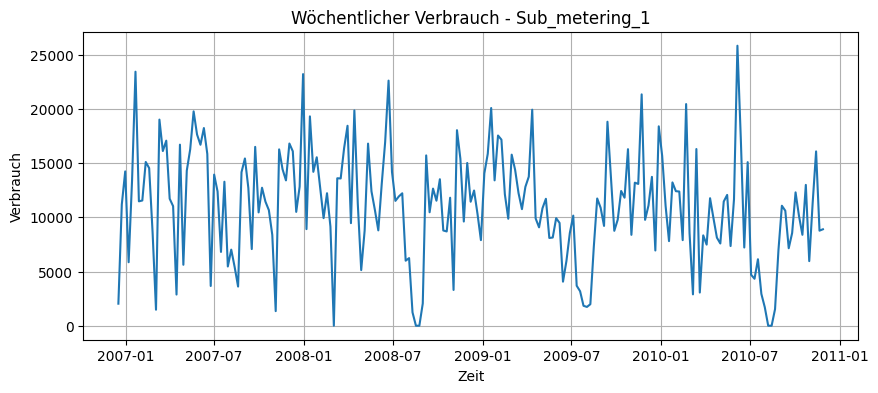

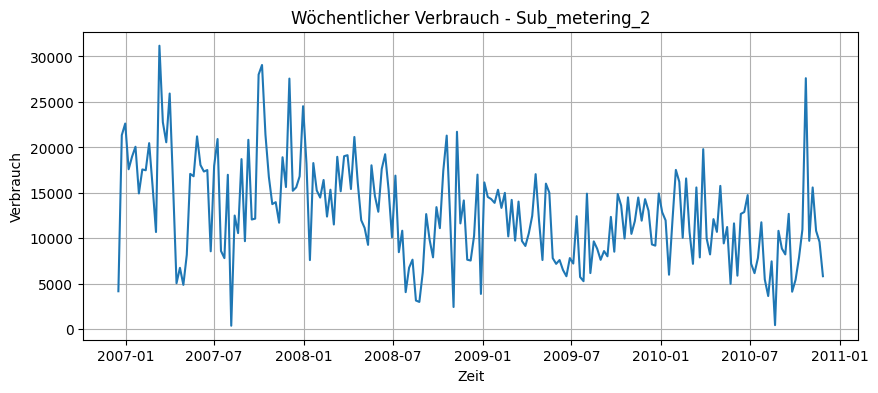

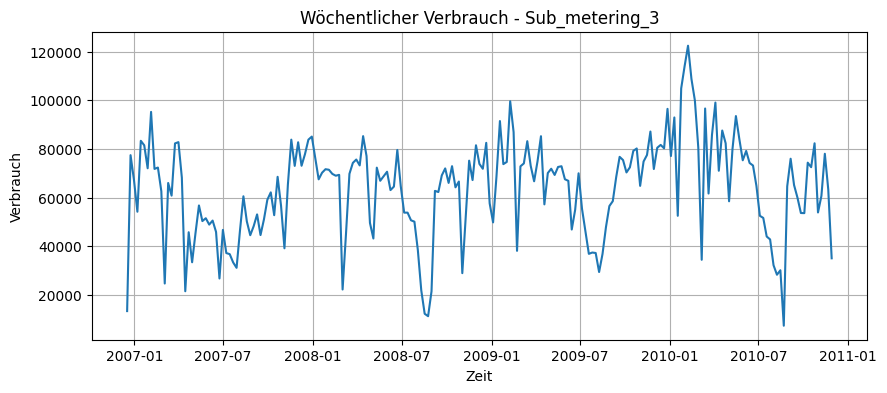

In [34]:
# Wochenverlauf
for col in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]:
    
    weekly = df_clean[col].resample("W").sum()
    
    plt.figure(figsize=(10,4))
    plt.plot(weekly)
    
    plt.title(f"Wöchentlicher Verbrauch - {col}")
    plt.xlabel("Zeit")
    plt.ylabel("Verbrauch")
    
    plt.grid()
    plt.show()

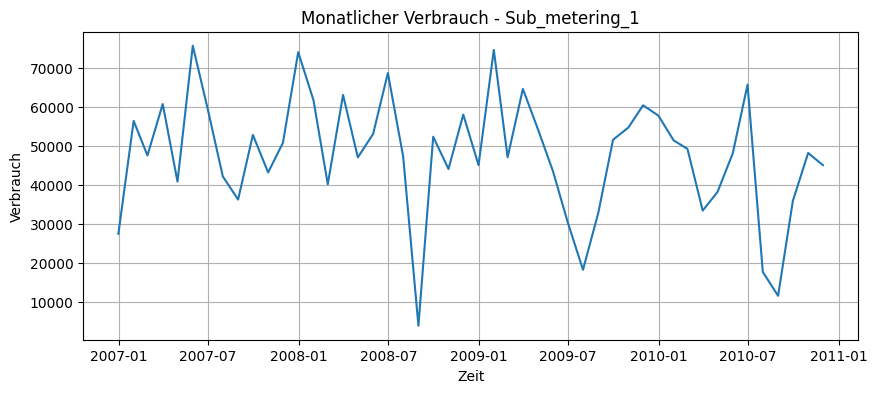

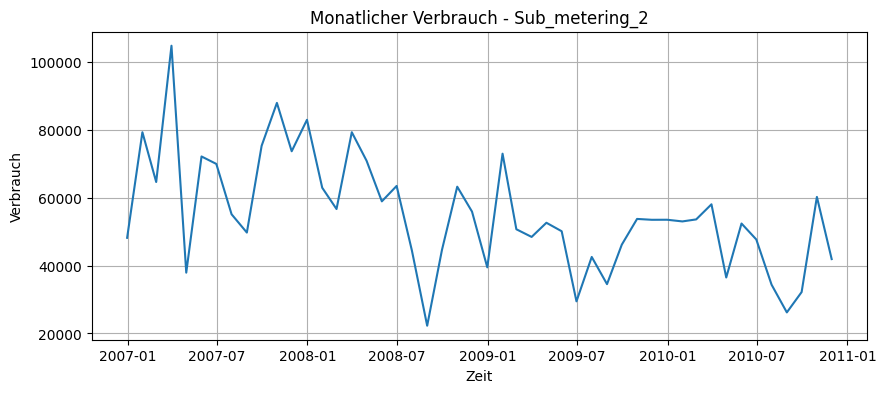

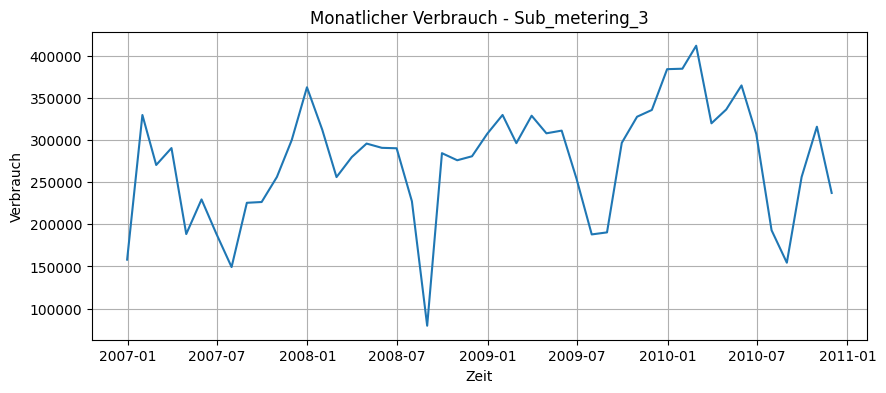

In [35]:
# Monatsverlauf
for col in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]:
    
    monthly = df_clean[col].resample("ME").sum()
    
    plt.figure(figsize=(10,4))
    plt.plot(monthly)
    
    plt.title(f"Monatlicher Verbrauch - {col}")
    plt.xlabel("Zeit")
    plt.ylabel("Verbrauch")
    
    plt.grid()
    plt.show()

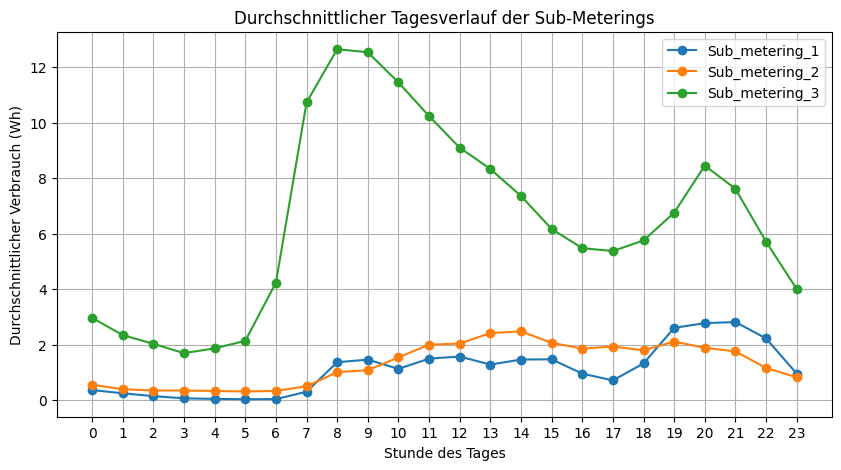

In [36]:
# Durchschnittlicher Tagesverlauf der drei Sub-Meterings

submeterings = ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]

# Stunde aus dem Zeitindex ableiten
df_clean["hour"] = df_clean.index.hour

# Durchschnitt pro Stunde berechnen
hourly_submeterings = df_clean.groupby("hour")[submeterings].mean()

# Labels
labels = {
    "Sub_metering_1": "Küche",
    "Sub_metering_2": "Waschen",
    "Sub_metering_3": "Warmwasser/Klimaanlage"
}


# Visualisierung
plt.figure(figsize=(10,5))

for col in submeterings:
    plt.plot(hourly_submeterings.index, hourly_submeterings[col], marker="o", label=col)

plt.title("Durchschnittlicher Tagesverlauf der Sub-Meterings")
plt.xlabel("Stunde des Tages")
plt.ylabel("Durchschnittlicher Verbrauch (Wh)")

plt.xticks(range(0, 24))
plt.grid()
plt.legend()

plt.show()

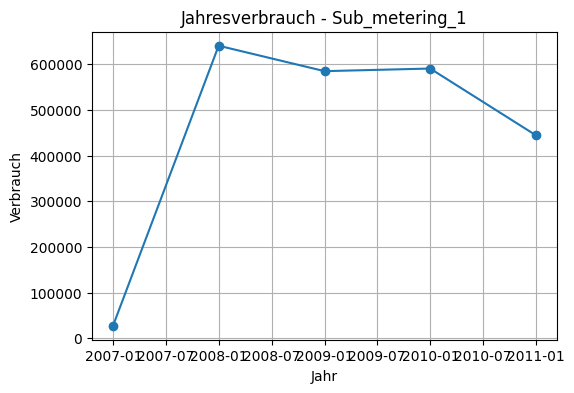

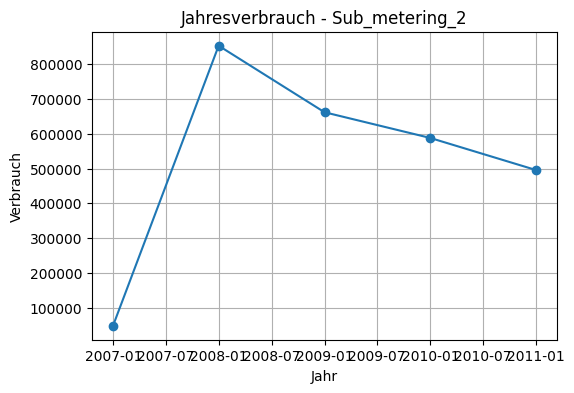

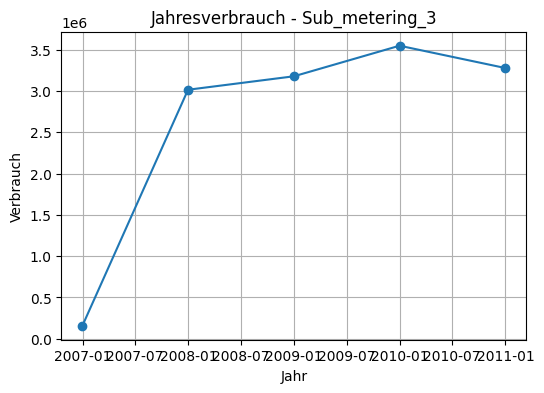

In [37]:
# Jahresvergleich
for col in ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]:
    
    yearly = df_clean[col].resample("YE").sum()
    
    plt.figure(figsize=(6,4))
    plt.plot(yearly, marker="o")
    
    plt.title(f"Jahresverbrauch - {col}")
    plt.xlabel("Jahr")
    plt.ylabel("Verbrauch")
    
    plt.grid()
    plt.show()

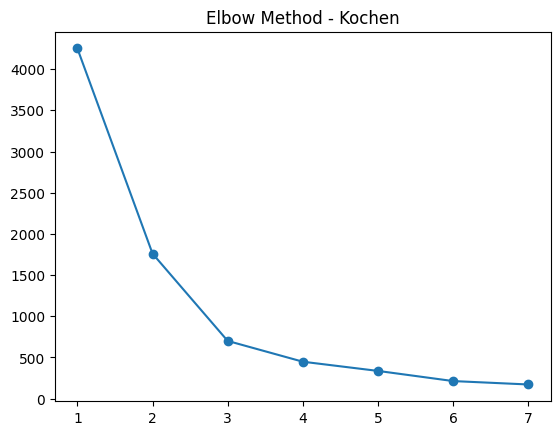

In [38]:
# 7. EXPLORATIV getestete Zusatzanalysen
# EXPLORATIV - Clustering der Sub-meterings
# Tagesaggregation Kochen sub-metering 1
cook = df_clean["Sub_metering_1"].resample("D").agg([
    "sum","max","std"
]).dropna()

# Standardisieren
scaler = StandardScaler()
scaled = scaler.fit_transform(cook)

# Elbow prüfen
inertia=[]

for k in range(1,8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,8), inertia, marker="o")
plt.title("Elbow Method - Kochen")
plt.show()

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)
cook["cluster"] = kmeans.fit_predict(scaled)

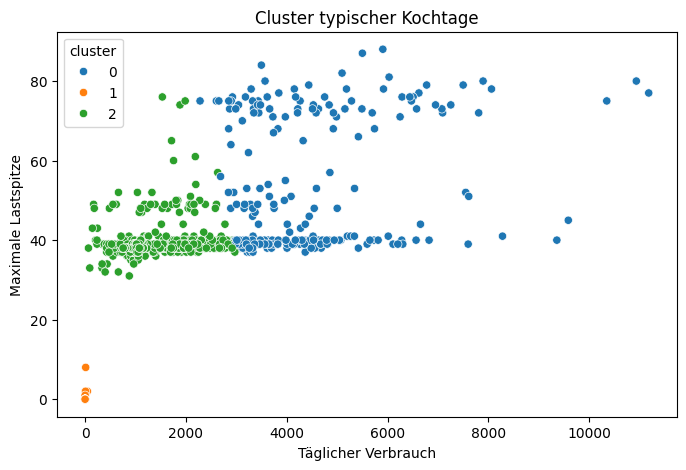

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cook,
    x="sum",
    y="max",
    hue="cluster",
    palette="tab10"
)

plt.title("Cluster typischer Kochtage")
plt.xlabel("Täglicher Verbrauch")
plt.ylabel("Maximale Lastspitze")

plt.show()

In [41]:
cook["weekday"]=cook.index.dayofweek

cook.groupby(["cluster","weekday"]).size()

cluster  weekday
0        0           15
         1           15
         2           27
         3           15
         4           17
         5           71
         6           83
1        0           49
         1           57
         2           35
         3           60
         4           52
         5           32
         6           31
2        0          139
         1          131
         2          142
         3          128
         4          135
         5           97
         6           86
dtype: int64

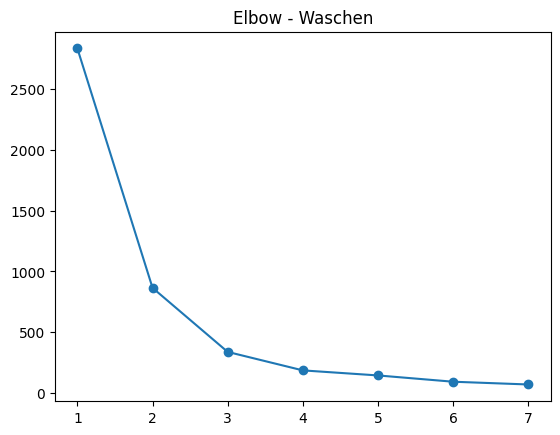

In [42]:
# Clustering sub-metering 2 - Waschverhalten
# Tagesaggregation
washing = df_clean["Sub_metering_2"].resample("D").agg([
    "sum", "max"
]).dropna()

# Standardisierung
scaler = StandardScaler()
scaled = scaler.fit_transform(washing)

# Elbow
inertia=[]

for k in range(1,8):
    km=KMeans(n_clusters=k, random_state=42)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,8), inertia, marker="o")
plt.title("Elbow - Waschen")
plt.show()

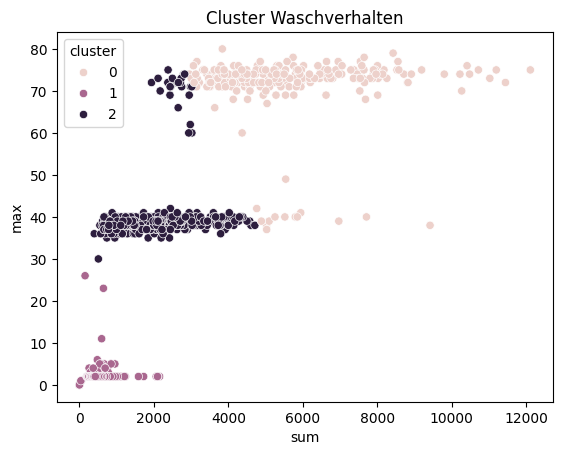

In [43]:
# Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
washing["cluster"] = kmeans.fit_predict(scaled)

# Visualisierung
sns.scatterplot(
    data=washing,
    x="sum",
    y="max",
    hue="cluster"
)

plt.title("Cluster Waschverhalten")
plt.show()

In [44]:
# Wochentag analysieren
washing["weekday"] = washing.index.dayofweek

washing.groupby(["cluster", "weekday"]).size()

cluster  weekday
0        0           19
         1           42
         2           54
         3           13
         4           26
         5           42
         6           65
1        0          147
         1          101
         2           81
         3          151
         4          138
         5           79
         6           69
2        0           37
         1           60
         2           69
         3           39
         4           40
         5           79
         6           66
dtype: int64

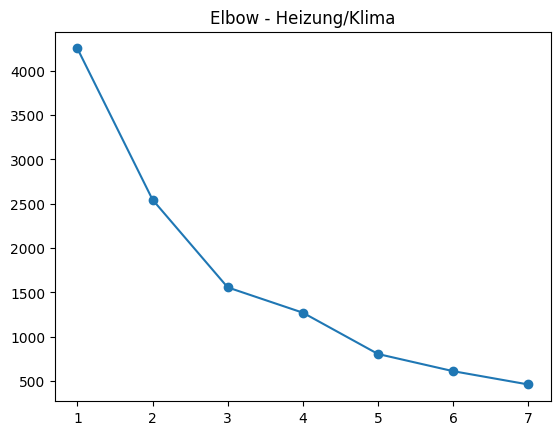

In [45]:
# Clustering sub-metering 3 - Heizung / Klima
hvac = df_clean["Sub_metering_3"].resample("D").agg([
    "sum","max","std"
]).dropna()

scaled=StandardScaler().fit_transform(hvac)

inertia=[]

for k in range(1,8):
    km=KMeans(n_clusters=k, random_state=42)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,8), inertia, marker="o")
plt.title("Elbow - Heizung/Klima")
plt.show()

In [46]:
kmeans=KMeans(n_clusters=3, random_state=42)
hvac["cluster"]=kmeans.fit_predict(scaled)

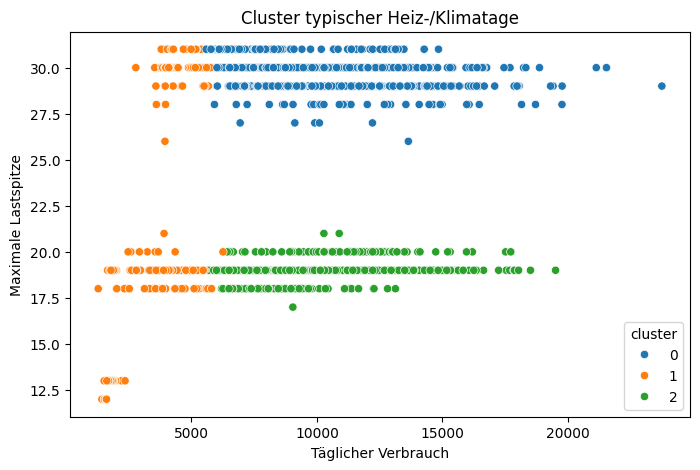

In [47]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=hvac,
    x="sum",
    y="max",
    hue="cluster",
    palette="tab10"
)

plt.title("Cluster typischer Heiz-/Klimatage")
plt.xlabel("Täglicher Verbrauch")
plt.ylabel("Maximale Lastspitze")

plt.show()

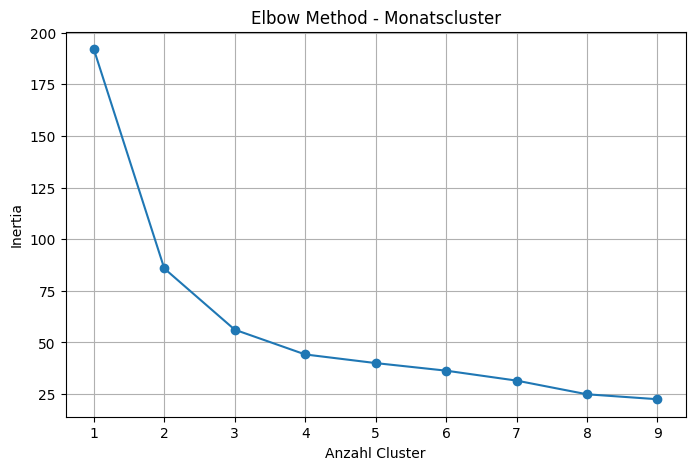

In [48]:
# EXPLORATIV - Clusteranalyse Monatsbasis
# Elbow Method Monatsbasis
inertia_monthly = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_monthly)
    inertia_monthly.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_monthly, marker="o")
plt.title("Elbow Method - Monatscluster")
plt.xlabel("Anzahl Cluster")
plt.ylabel("Inertia")
plt.grid()
plt.show()


In [50]:
# Clustering Monatsbasis
kmeans_monthly = KMeans(n_clusters=3, random_state=42)
monthly_features["cluster"] = kmeans_monthly.fit_predict(scaled_monthly)

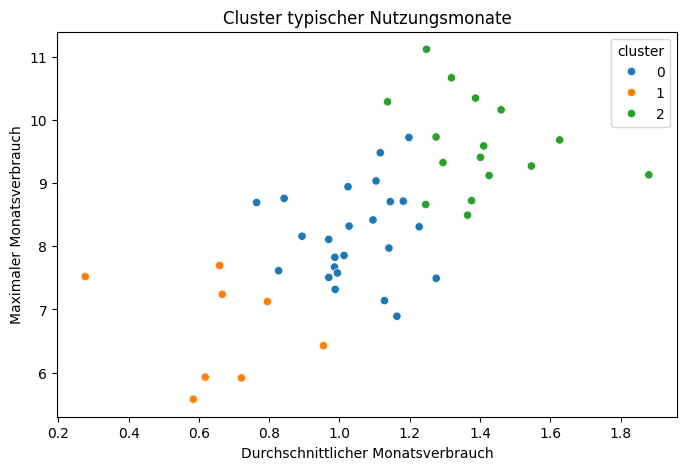

In [51]:
# Visualisierung Monatscluster
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=monthly_features,
    x="mean",
    y="max",
    hue="cluster",
    palette="tab10"
)
plt.title("Cluster typischer Nutzungsmonate")
plt.xlabel("Durchschnittlicher Monatsverbrauch")
plt.ylabel("Maximaler Monatsverbrauch")
plt.show()

In [52]:
# Clusteranalyse Monatsbasis
cluster_summary_monthly = monthly_features.groupby("cluster").mean()
cluster_summary_monthly["count"] = monthly_features["cluster"].value_counts().sort_index()
print("Cluster-Zusammenfassung Monatsbasis:")
print(cluster_summary_monthly)

print("\nVerteilung nach Kalendermonaten:")
print(monthly_features.groupby(["cluster", "month"]).size())

Cluster-Zusammenfassung Monatsbasis:
             mean       max         sum       std   month  count
cluster                                                         
0        1.044058  8.177167  748.893882  0.971934  6.5000     24
1        0.659310  6.678750  461.705600  0.687020  7.6250      8
2        1.399648  9.608875  965.573062  1.202477  5.9375     16

Verteilung nach Kalendermonaten:
cluster  month
0        2        1
         3        2
         4        4
         5        4
         6        4
         8        1
         9        3
         10       3
         11       1
         12       1
1        7        4
         8        3
         9        1
2        1        4
         2        3
         3        2
         10       1
         11       3
         12       3
dtype: int64


In [53]:
# Cluster aus monthly_features auf df übertragen
df_clean["year_month"] = df_clean.index.to_period("M")
monthly_features["year_month"] = monthly_features.index.to_period("M")
monthly_features = monthly_features.set_index("year_month")

df_clean = df_clean.join(monthly_features[["cluster"]], on="year_month")

Vorhandene Cluster: [np.int32(0), np.int32(1), np.int32(2)]
Cluster 0: 1032317 Zeilen
Cluster 1: 338390 Zeilen
Cluster 2: 669462 Zeilen


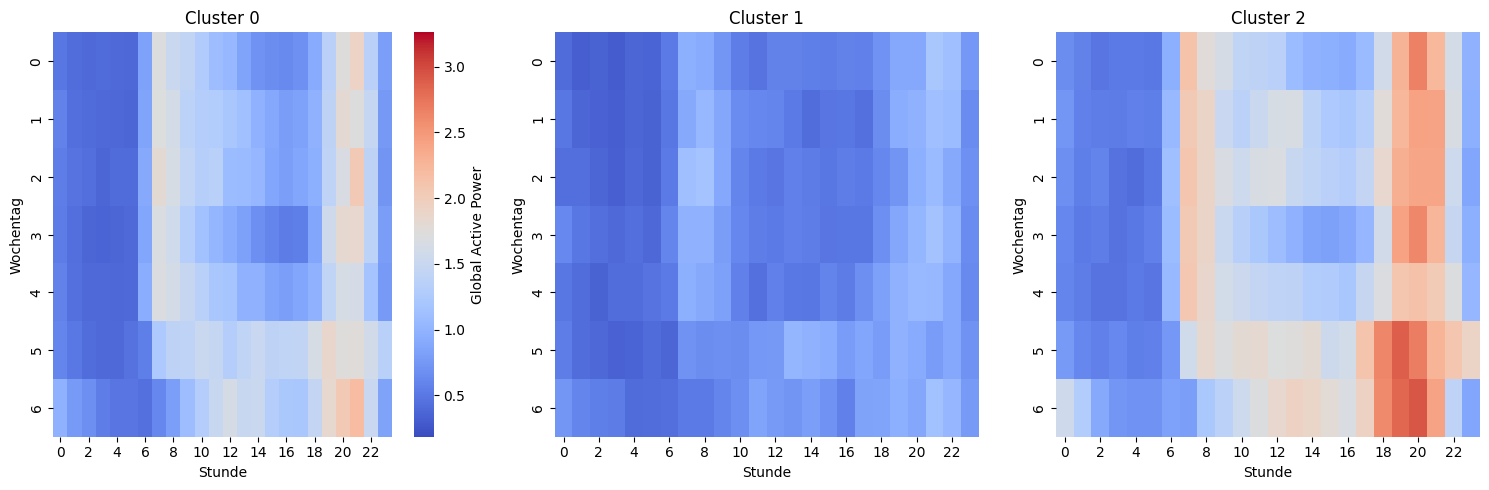

In [54]:
# vorhandene Cluster bestimmen
clusters = sorted(df_clean["cluster"].dropna().unique())
print("Vorhandene Cluster:", clusters)

# einheitliche Farbskala
vmin = df_clean["Global_active_power"].quantile(0.05)
vmax = df_clean["Global_active_power"].quantile(0.95)

# Anzahl Subplots dynamisch anpassen
fig, axes = plt.subplots(1, len(clusters), figsize=(5 * len(clusters), 5), squeeze=False)
axes = axes[0]

for i, c in enumerate(clusters):
    df_c = df_clean[df_clean["cluster"] == c].copy()

    print(f"Cluster {c}: {len(df_c)} Zeilen")

    pivot = df_c.pivot_table(
        values="Global_active_power",
        index="weekday",
        columns="hour",
        aggfunc="mean"
    )

    sns.heatmap(
        pivot,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        ax=axes[i],
        cbar=(i == 0),
        cbar_kws={"label": "Global Active Power"} if i == 0 else None
    )

    axes[i].set_title(f"Cluster {c}")
    axes[i].set_xlabel("Stunde")
    axes[i].set_ylabel("Wochentag")

plt.tight_layout()
plt.show()